# 工业企业财务数据

## 1 初识工业企业财务数据

利润表|资产负债表
-|-
营业收入|货币资金
-营业成本|应收账款
**毛利**|存货
-营业税金及附加|其它流动资产
-销售费用|**流动资产**
-管理费用|固定资产
-财务费用|无形资产
-资产减值损失|其他非流动性资产
+公允价值变动收益|**总资产**
+投资收益|流动负债
**营业利润**|非流动负债
+营业外收入|**总负债**
-营业外支出|**所有者权益**
**利润总额**
-所得税
**净利润**

## 2 工业企业利润表解读

### 2.1 工业企业利润表结构分析

统计局按月公布工业企业的营业收入、利润总额，比a股上市公司的季报时效性更高。

2019年后主营业务收入（成本）被营业收入（成本）替代，因为两者差距比较小，可以直接衔接起来。

股票价格 = 市盈率（PE）*每股收益（EPS）

如果把利润总额增速近似看成EPS增速，那么分析工业企业利润增速可以帮助我们对股票定价。

In [1]:
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

In [2]:
industryFinancialDf = ak.macro_china_nbs_nation(kind="月度数据", path="工业>工业企业主要经济指标", period="2011-")
industryFinancialDf = industryFinancialDf.transpose().iloc[::-1]

In [3]:
ppiDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="价格指数>工业生产者出厂价格分类指数>工业生产者出厂价格指数(上年同期=100)",
    period="2011-",
)
ppiDf = ppiDf.transpose().iloc[::-1]

In [4]:
gyzjzDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="工业>工业增加值增长速度", period="2011-"
)
gyzjzDf = gyzjzDf.transpose().iloc[::-1]

In [5]:
profitByCategoriesDf = ak.macro_china_nbs_nation(
    kind="月度数据",
    path="工业>按行业分工业企业主要经济指标(2018-至今)>工业企业利润总额",
    period="2018-",
)
profitByCategoriesDf = profitByCategoriesDf.transpose().iloc[::-1]

<Axes: title={'center': '工业企业利润总额增速'}>

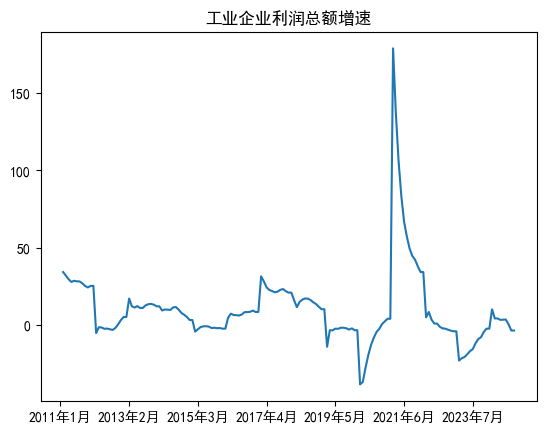

In [6]:
industryFinancialDf['利润总额_累计增长(%)'].ffill().plot(title="工业企业利润总额增速")

### 2.2 工业企业利润数据分析

#### 2.2.1 从总量角度观察

工业企业利润=营业收入*利润率

那么可以把这个公式中的每一项往统计局公布的数据中套，找一些关联性强的指标进行分析。

工业企业利润变动的原因可以拆成3部分：量、价、利润率

1. 产量的变动可以通过工业增加值同比观察

    工业增加值同比，剔除了价格因素（ppi），所以是一个很纯粹的、只反映总产量（或者说实际总产值）变动的指标

2. 价格的变动可以通过ppi同比观察

3. 利润率的变动可以通过营业收入利润率观察（营业收入利润率= (营业收入-营业成本-税金及附加-期间费用)÷营业收入×100% ）


In [7]:
industryFinancialDf2018 = industryFinancialDf.ffill().loc["2018年1月":]
profitRate2018 = (
    industryFinancialDf2018["营业利润_累计值(亿元)"]
    / industryFinancialDf2018["营业收入_累计值(亿元)"]
) / (
    industryFinancialDf2018["营业利润_上年同期累计值(亿元)"]
    / industryFinancialDf2018["营业收入_上年同期累计值(亿元)"]
) * 100 - 100

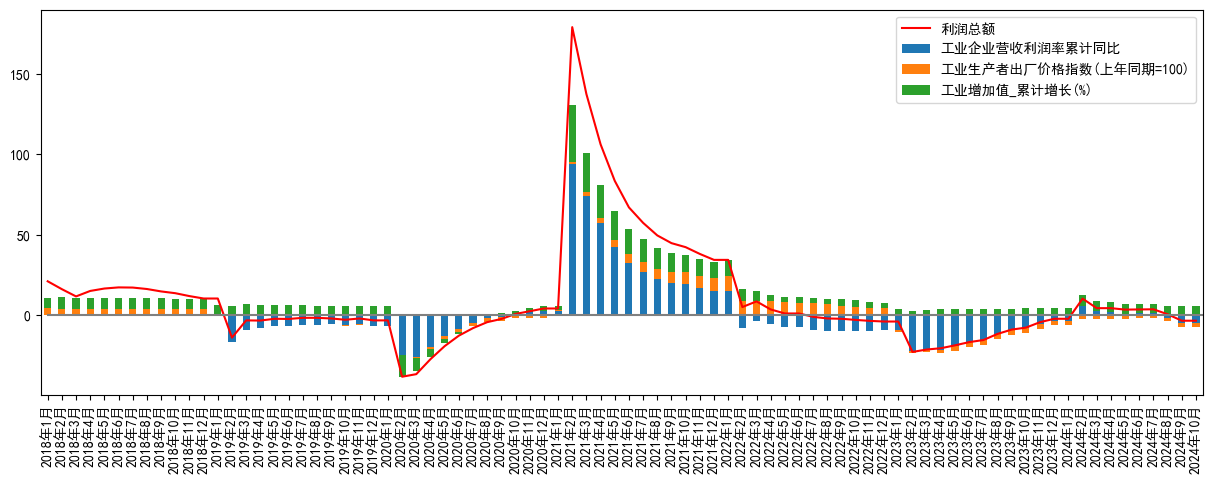

In [8]:
ax = pd.DataFrame(
    {
        "工业企业营收利润率累计同比": profitRate2018,
        "工业生产者出厂价格指数(上年同期=100)": ppiDf[
            "工业生产者出厂价格指数(上年同期=100)"
        ]
        .ffill()
        .loc["2018年1月":]
        - 100,
        "工业增加值_累计增长(%)": gyzjzDf["工业增加值_累计增长(%)"]
        .ffill()
        .loc["2018年1月":],
    }
).plot(figsize=(15, 5), kind="bar", stacked=True)
ax.plot(
    industryFinancialDf["利润总额_累计增长(%)"].ffill().loc["2018年1月":],
    label="利润总额",
    color="r",
)
ax.plot([0]*industryFinancialDf["利润总额_累计增长(%)"].size, color="gray")
plt.legend()

#### 2.2.2 从行业角度观察

<Axes: >

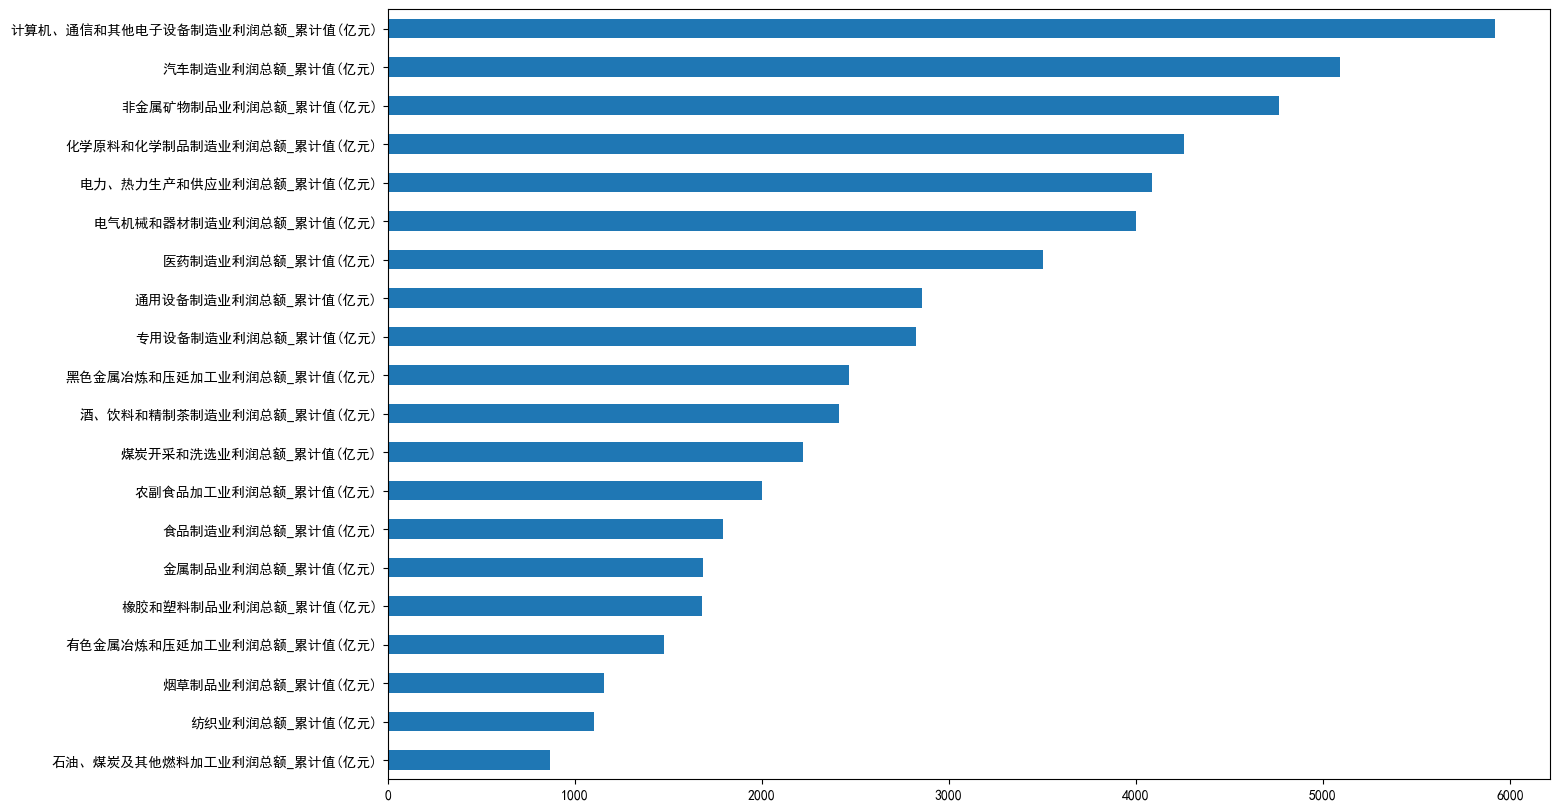

In [22]:
import hy

values = []
index = []
industryHy = hy.getIndustryHYCode()
for (code, name) in industryHy:
    if len(code) == 2:
        values.append(profitByCategoriesDf.loc["2020年12月"][f"{name}利润总额_累计值(亿元)"])
        index.append(f"{name}利润总额_累计值(亿元)")
s = pd.Series(values, index=index).sort_values(ascending=True)
s.iloc[-20:].plot.barh(figsize=(15,10))

In [19]:
len(profitByCategoriesDf.columns)

135